# Customer Analytics: Data Preprocessing, EDA, RFM & Cohort Analysis

Notebook ini mencakup alur analitik pelanggan end-to-end menggunakan dataset **UCI Online Retail II**, mulai dari preprocessing data mentah hingga menghasilkan tabel RFM tersegmentasi dan matriks retensi cohort.

**Alur kerja:**
1. Setup & Audit Dataset
2. Data Cleaning & Validasi
3. Exploratory Data Analysis (EDA)
4. RFM Feature Engineering & Segmentasi
5. Cohort Retention Analysis
6. Export Output

---
## 1. Setup & Audit Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

sns.set_theme(style="whitegrid")

In [2]:
# Sesuaikan path dataset dengan lokasi file di mesin kamu
DATA_PATH = 'online_retail_II.csv'

df = pd.read_csv(DATA_PATH)
print("Kolom dataset:", df.columns.tolist())

Kolom dataset: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [3]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Jumlah baris          : {len(df):,}")
print(f"Customer unik         : {df['Customer ID'].nunique():,}")
print(f"Invoice unik          : {df['Invoice'].nunique():,}")
print(f"Rentang tanggal       : {df['InvoiceDate'].min().date()} s/d {df['InvoiceDate'].max().date()}")
print(f"\nMissing value per kolom:\n{df.isnull().sum()}")
print(f"\nBaris duplikat        : {df.duplicated().sum():,}")

n_cancelled = df['Invoice'].astype(str).str.startswith('C').sum()
print(f"Transaksi pembatalan  : {n_cancelled:,}")

Jumlah baris          : 1,067,371
Customer unik         : 5,942
Invoice unik          : 53,628
Rentang tanggal       : 2009-12-01 s/d 2011-12-09

Missing value per kolom:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Baris duplikat        : 34,335
Transaksi pembatalan  : 19,494


---
## 2. Data Cleaning & Validasi

Langkah pembersihan:
- Hapus baris dengan `Customer ID` kosong
- Hapus invoice pembatalan (prefix `C`)
- Pertahankan hanya transaksi dengan `Quantity > 0` dan `Price > 0`
- Buat kolom `TotalPrice` = `Quantity × Price`

In [4]:
df_clean = df.copy()

df_clean = df_clean.dropna(subset=['Customer ID'])
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

removed = len(df) - len(df_clean)
print(f"Baris sebelum cleaning : {len(df):,}")
print(f"Baris setelah cleaning : {len(df_clean):,}")
print(f"Baris yang dihapus     : {removed:,} ({removed/len(df)*100:.1f}%)")

Baris sebelum cleaning : 1,067,371
Baris setelah cleaning : 805,549
Baris yang dihapus     : 261,822 (24.5%)


In [5]:
df_clean.to_csv('clean_transactions.csv', index=False)
print("Output disimpan: clean_transactions.csv")

Output disimpan: clean_transactions.csv


---
## 3. Exploratory Data Analysis (EDA)

In [6]:
top_customers = (
    df_clean.groupby('Customer ID')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("Top 10 Customer berdasarkan Total Revenue:")
print(top_customers.to_string())

Top 10 Customer berdasarkan Total Revenue:
Customer ID
18102.0    608821.65
14646.0    528602.52
14156.0    313946.37
14911.0    295972.63
17450.0    246973.09
13694.0    196482.81
17511.0    175603.55
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37


/tmp/ipykernel_123268/3172225260.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='viridis')


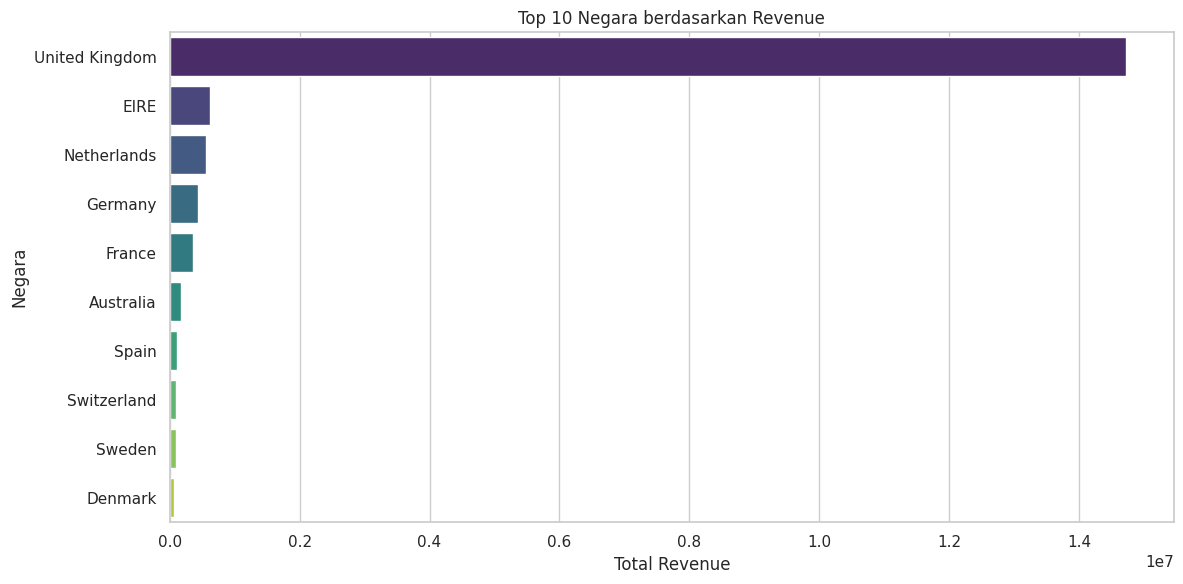

In [7]:
country_revenue = (
    df_clean.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='viridis')
plt.title('Top 10 Negara berdasarkan Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Negara')
plt.tight_layout()
plt.show()

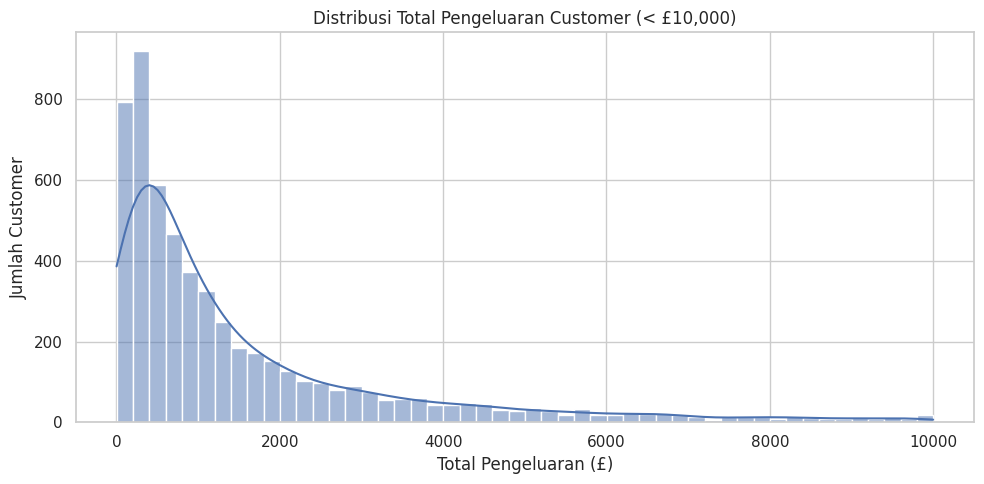

In [8]:
spending = df_clean.groupby('Customer ID')['TotalPrice'].sum()

plt.figure(figsize=(10, 5))
sns.histplot(spending[spending < 10_000], bins=50, kde=True)
plt.title('Distribusi Total Pengeluaran Customer (< £10,000)')
plt.xlabel('Total Pengeluaran (£)')
plt.ylabel('Jumlah Customer')
plt.tight_layout()
plt.show()

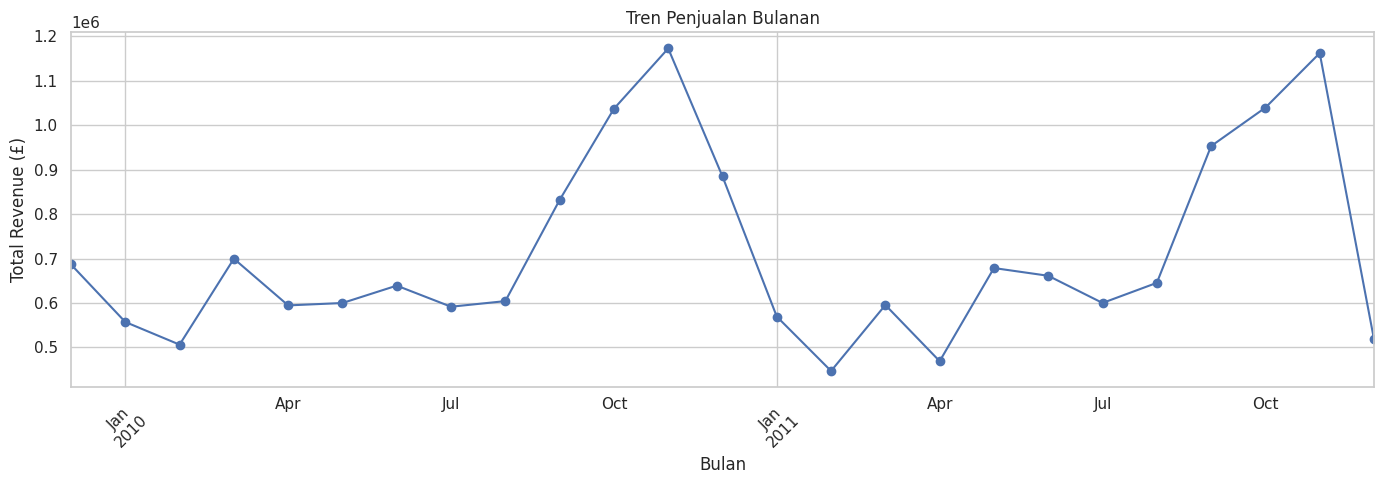

In [9]:
df_clean['MonthYear'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_sales = df_clean.groupby('MonthYear')['TotalPrice'].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(marker='o')
plt.title('Tren Penjualan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 4. RFM Feature Engineering & Segmentasi

**RFM** mengukur tiga dimensi perilaku pelanggan:
- **Recency** — seberapa baru terakhir kali transaksi (hari)
- **Frequency** — berapa kali transaksi unik
- **Monetary** — total nilai pembelian

Setiap dimensi diberi skor 1–5, lalu digabung menjadi `RF_Score` untuk menentukan segmen.

In [10]:
reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

rfm = df_clean.groupby('Customer ID').agg(
    Recency  = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency= ('Invoice',     'nunique'),
    Monetary = ('TotalPrice',  'sum')
)

rfm.head()

Reference date: 2011-12-10


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [11]:
# Recency: skor 5 = paling baru (nilai terkecil)
rfm['RecencyScore'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# Frequency: rank method digunakan karena banyak customer dengan nilai yang sama
rfm['FrequencyScore'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# Monetary: skor 5 = pengeluaran tertinggi
rfm['MonetaryScore'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RF_Score'] = rfm['RecencyScore'].astype(str) + rfm['FrequencyScore'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RF_Score
Customer ID,,,,,,,
12346.0,326,12,77556.46,2,5,5,25
12347.0,2,8,5633.32,5,4,5,54
12348.0,75,5,2019.40,3,4,4,34
12349.0,19,4,4428.69,5,3,5,53
12350.0,310,1,334.40,2,1,2,21


In [12]:
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5':     "Can't Lose",
    r'3[1-2]':     'About To Sleep',
    r'33':         'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41':         'Promising',
    r'51':         'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]':     'Champions'
}

rfm['Segment'] = rfm['RF_Score'].replace(seg_map, regex=True)

print("Distribusi Segmen RFM:")
print(rfm['Segment'].value_counts())

Distribusi Segmen RFM:
Segment
Hibernating            1523
Loyal Customers        1161
Champions               837
At Risk                 753
Potential Loyalists     714
About To Sleep          385
Need Attention          266
Promising               114
Can't Lose               71
New Customers            54
Name: count, dtype: int64


### 4.1 Validasi RFM — Deteksi Outlier

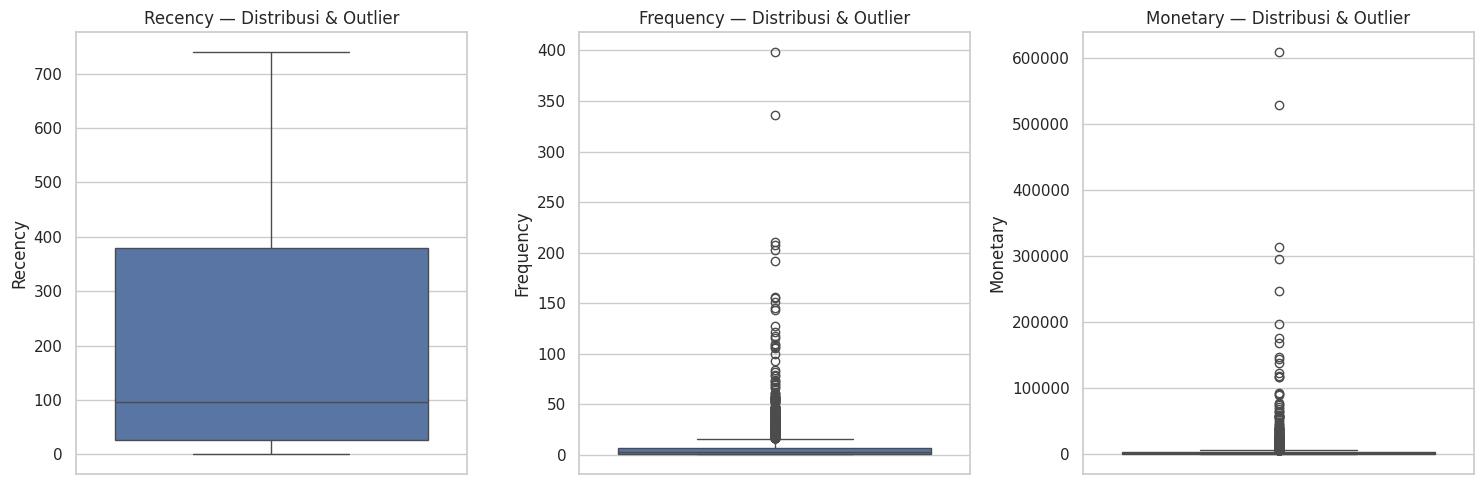

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(y=rfm[col], ax=ax)
    ax.set_title(f'{col} — Distribusi & Outlier')

plt.tight_layout()
plt.show()

In [14]:
rfm_profile = rfm.groupby('Segment').agg(
    Jumlah_Customer = ('Recency', 'count'),
    Recency_Rata2   = ('Recency', 'mean'),
    Frequency_Rata2 = ('Frequency', 'mean'),
    Monetary_Rata2  = ('Monetary', 'mean')
).round(2)

print("Profil per Segmen RFM:")
rfm_profile

Profil per Segmen RFM:


,Jumlah_Customer,Recency_Rata2,Frequency_Rata2,Monetary_Rata2
Segment,,,,
About To Sleep,385,107.11,1.36,534.07
At Risk,753,372.67,3.90,1382.10
Can't Lose,71,331.23,15.93,8355.68
Champions,837,8.56,19.34,10901.13
Hibernating,1523,459.28,1.25,438.03
Loyal Customers,1161,67.07,9.84,4211.84
Need Attention,266,113.36,3.15,1283.66
New Customers,54,10.50,1.00,360.67
Potential Loyalists,714,25.76,2.59,1155.71


---
## 5. Cohort Retention Analysis

Cohort dibentuk berdasarkan **kuartal pertama** seorang customer melakukan transaksi. Matriks retensi menunjukkan persentase customer yang kembali bertransaksi di kuartal-kuartal berikutnya.

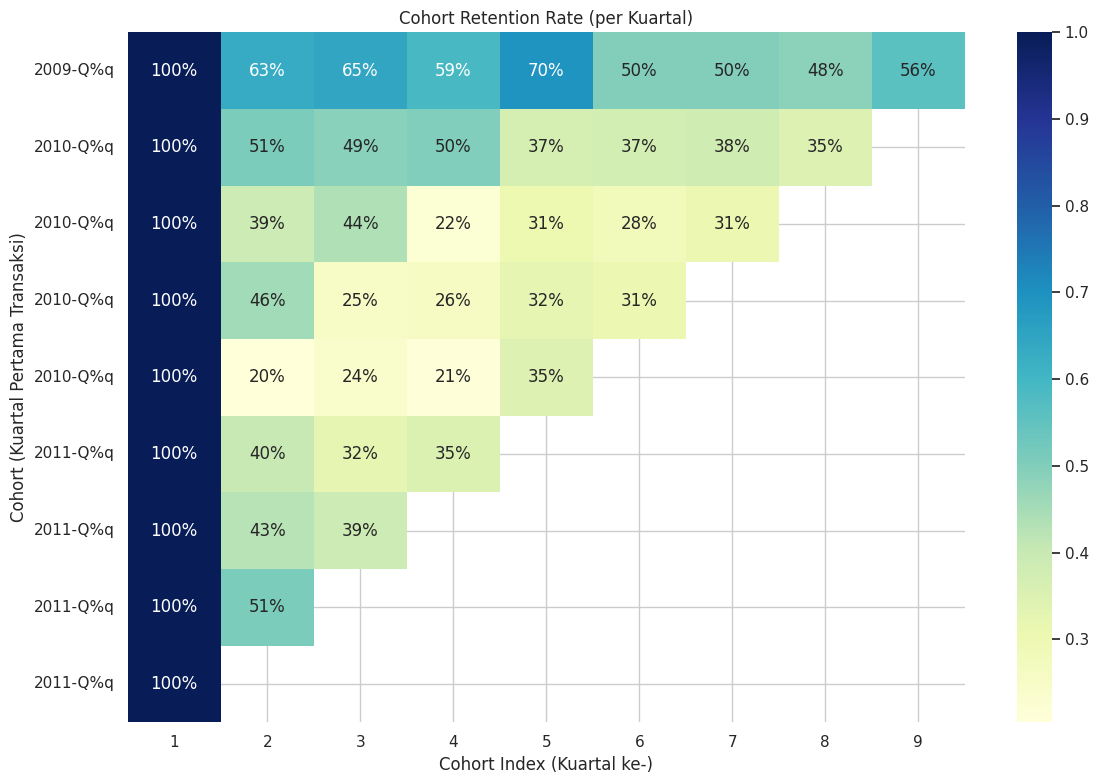

In [15]:
def get_quarter_start(date):
    """Kembalikan tanggal awal kuartal dari suatu datetime."""
    return dt.datetime(date.year, (date.month - 1) // 3 * 3 + 1, 1)

df_clean['InvoiceQuarter'] = df_clean['InvoiceDate'].apply(get_quarter_start)
df_clean['CohortQuarter']  = df_clean.groupby('Customer ID')['InvoiceQuarter'].transform('min')

# Hitung jarak antar kuartal sebagai cohort index
years_diff    = df_clean['InvoiceQuarter'].dt.year    - df_clean['CohortQuarter'].dt.year
quarters_diff = df_clean['InvoiceQuarter'].dt.quarter - df_clean['CohortQuarter'].dt.quarter
df_clean['CohortIndex'] = years_diff * 4 + quarters_diff + 1

# Bangun matriks retensi
cohort_data = (
    df_clean.groupby(['CohortQuarter', 'CohortIndex'])['Customer ID']
    .nunique()
    .reset_index()
)
cohort_counts = cohort_data.pivot(
    index='CohortQuarter', columns='CohortIndex', values='Customer ID'
)

cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)
retention.index = retention.index.strftime('%Y-Q%q')

plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Cohort Retention Rate (per Kuartal)')
plt.xlabel('Cohort Index (Kuartal ke-)')
plt.ylabel('Cohort (Kuartal Pertama Transaksi)')
plt.tight_layout()
plt.show()

---
## 6. Export Output

In [16]:
# Tambahkan kolom Country ke tabel RFM
customer_country = df_clean.groupby('Customer ID')['Country'].first()
rfm = rfm.join(customer_country)

# Simpan hasil
rfm.to_csv('rfm_customer_table.csv')
retention.to_csv('cohort_retention_matrix.csv')

print("Output tersimpan:")
print("  - rfm_customer_table.csv")
print("  - cohort_retention_matrix.csv")

Output tersimpan:
  - rfm_customer_table.csv
  - cohort_retention_matrix.csv
